In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [18]:
df = pd.read_csv("../data/raw/job_search_platform_efficacy_100k.csv")

In [19]:
print("Shape:", df.shape)

Shape: (100000, 20)


In [20]:

df.head()

,Student_ID,University_Rating,School_Size,Region,Major_Category,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received,Time_to_Offer_Days,Offer_Salary,Company_Size_Offered,Role_Relevance,Accepted_Offer
0,STU_000001,Mid-tier,Medium,West,Healthcare,2.81,3,2,6,LinkedIn,1,9,2,2,1,46.0,59785.0,Mid-Size,9.0,1.0
1,STU_000002,Lower-tier,Medium,Northeast,STEM,2.61,1,1,6,Handshake,1,5,1,0,0,NaN,NaN,NaN,NaN,NaN
2,STU_000003,Lower-tier,Medium,Midwest,STEM,3.53,3,2,2,Handshake,5,34,3,1,0,NaN,NaN,NaN,NaN,NaN
3,STU_000004,Mid-tier,Medium,Midwest,Business,2.73,0,2,1,Handshake,2,10,0,0,0,NaN,NaN,NaN,NaN,NaN
4,STU_000005,Mid-tier,Medium,South,Business,4.00,1,0,1,Indeed,5,65,0,0,0,NaN,NaN,NaN,NaN,NaN


In [21]:
print("\nColumns:\n", df.columns.tolist())


Columns:
 ['Student_ID', 'University_Rating', 'School_Size', 'Region', 'Major_Category', 'GPA', 'Prior_Internships', 'Extra_Curricular_Activities', 'Networking_Events_Attended', 'Primary_Search_Platform', 'Months_Searching', 'Applications_Submitted', 'First_Round_Interviews', 'Second_Round_Interviews', 'Offer_Received', 'Time_to_Offer_Days', 'Offer_Salary', 'Company_Size_Offered', 'Role_Relevance', 'Accepted_Offer']


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Student_ID                   100000 non-null  object 
 1   University_Rating            100000 non-null  object 
 2   School_Size                  100000 non-null  object 
 3   Region                       100000 non-null  object 
 4   Major_Category               100000 non-null  object 
 5   GPA                          100000 non-null  float64
 6   Prior_Internships            100000 non-null  int64  
 7   Extra_Curricular_Activities  100000 non-null  int64  
 8   Networking_Events_Attended   100000 non-null  int64  
 9   Primary_Search_Platform      100000 non-null  object 
 10  Months_Searching             100000 non-null  int64  
 11  Applications_Submitted       100000 non-null  int64  
 12  First_Round_Interviews       100000 non-null  int64  
 13  

In [23]:
df.isnull().sum()

Student_ID                         0
University_Rating                  0
School_Size                        0
Region                             0
Major_Category                     0
GPA                                0
Prior_Internships                  0
Extra_Curricular_Activities        0
Networking_Events_Attended         0
Primary_Search_Platform            0
Months_Searching                   0
Applications_Submitted             0
First_Round_Interviews             0
Second_Round_Interviews            0
Offer_Received                     0
Time_to_Offer_Days             65771
Offer_Salary                   65771
Company_Size_Offered           65771
Role_Relevance                 65771
Accepted_Offer                 65771
dtype: int64

In [24]:
drop_cols = [
    "Student_ID",
    "First_Round_Interviews",
    "Second_Round_Interviews",
    "Time_to_Offer_Days",
    "Offer_Salary",
    "Company_Size_Offered",
    "Role_Relevance",
    "Accepted_Offer"
]

In [25]:
df = df.drop(columns=drop_cols)

In [26]:
df.shape

(100000, 12)

In [27]:
X = df.drop("Offer_Received", axis=1)
y = df["Offer_Received"]

In [35]:
y.value_counts()

Offer_Received
0    65771
1    34229
Name: count, dtype: int64

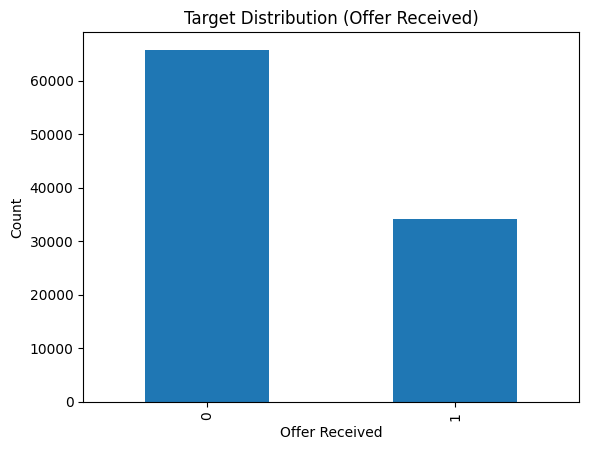

In [42]:
y.value_counts().plot(kind='bar')

plt.title("Target Distribution (Offer Received)")
plt.xlabel("Offer Received")
plt.ylabel("Count")

plt.show()

In [36]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Columns:\n", cat_cols)
print("\nNumerical Columns:\n", num_cols)

Categorical Columns:
 ['University_Rating', 'School_Size', 'Region', 'Major_Category', 'Primary_Search_Platform']

Numerical Columns:
 ['GPA', 'Prior_Internships', 'Extra_Curricular_Activities', 'Networking_Events_Attended', 'Months_Searching', 'Applications_Submitted']


In [37]:
X[num_cols].describe()

,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.196631,1.19697,2.003990,2.998600,6.499680,53.727620
std,0.392370,1.12192,1.413709,1.734494,3.443719,45.004663
min,2.000000,0.00000,0.000000,0.000000,1.000000,5.000000
25%,2.930000,0.00000,1.000000,2.000000,4.000000,19.000000
50%,3.200000,1.00000,2.000000,3.000000,6.000000,42.000000
75%,3.470000,2.00000,3.000000,4.000000,9.000000,75.000000
max,4.000000,5.00000,11.000000,14.000000,12.000000,300.000000


In [38]:
eda_num = pd.concat([X[num_cols], y], axis=1)

eda_num.groupby("Offer_Received")[num_cols].mean()

,GPA,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,Months_Searching,Applications_Submitted
Offer_Received,,,,,,
0,3.171875,1.016846,1.998282,2.997385,6.37585,53.350884
1,3.244201,1.543078,2.014958,3.000935,6.73762,54.451518


In [39]:
for col in cat_cols:
    print(f"\n===== {col} =====")
    print(pd.crosstab(X[col], y, normalize='index'))


===== University_Rating =====
Offer_Received            0         1
University_Rating                    
Lower-tier         0.668440  0.331560
Mid-tier           0.668326  0.331674
Top-tier           0.597363  0.402637

===== School_Size =====
Offer_Received         0         1
School_Size                       
Large           0.659439  0.340561
Medium          0.661019  0.338981
Small           0.647605  0.352395

===== Region =====
Offer_Received         0         1
Region                            
Midwest         0.657753  0.342247
Northeast       0.660090  0.339910
South           0.655604  0.344396
West            0.657404  0.342596

===== Major_Category =====
Offer_Received         0         1
Major_Category                    
Arts            0.675497  0.324503
Business        0.644678  0.355322
Healthcare      0.671606  0.328394
Humanities      0.671058  0.328942
STEM            0.654692  0.345308

===== Primary_Search_Platform =====
Offer_Received                  0      

In [40]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.67865

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.93      0.79     13054
           1       0.61      0.21      0.32      6946

    accuracy                           0.68     20000
   macro avg       0.65      0.57      0.55     20000
weighted avg       0.66      0.68      0.63     20000



In [45]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6257

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.65      0.69     13054
           1       0.47      0.59      0.52      6946

    accuracy                           0.63     20000
   macro avg       0.61      0.62      0.61     20000
weighted avg       0.65      0.63      0.63     20000



In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.62565

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.65      0.69     13054
           1       0.47      0.59      0.52      6946

    accuracy                           0.63     20000
   macro avg       0.61      0.62      0.61     20000
weighted avg       0.65      0.63      0.63     20000



In [49]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5867

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.68      0.68     13054
           1       0.41      0.42      0.41      6946

    accuracy                           0.59     20000
   macro avg       0.55      0.55      0.55     20000
weighted avg       0.59      0.59      0.59     20000



In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.66845

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.89      0.78     13054
           1       0.55      0.25      0.34      6946

    accuracy                           0.67     20000
   macro avg       0.62      0.57      0.56     20000
weighted avg       0.64      0.67      0.63     20000



In [51]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.66905

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.90      0.78     13054
           1       0.56      0.24      0.33      6946

    accuracy                           0.67     20000
   macro avg       0.62      0.57      0.56     20000
weighted avg       0.64      0.67      0.62     20000



In [52]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.68235

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.94      0.79     13054
           1       0.64      0.20      0.30      6946

    accuracy                           0.68     20000
   macro avg       0.66      0.57      0.55     20000
weighted avg       0.67      0.68      0.62     20000



In [53]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [54]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

c:\Users\Om Mishra\.conda\envs\job_env\lib\site-packages\xgboost\training.py:200: UserWarning: [02:21:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.67655

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.91      0.79     13054
           1       0.58      0.24      0.34      6946

    accuracy                           0.68     20000
   macro avg       0.64      0.57      0.56     20000
weighted avg       0.65      0.68      0.63     20000



In [55]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [56]:
threshold = 0.4  # we will tune this later

y_pred_custom = (y_prob >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("\nClassification Report:\n", classification_report(y_test, y_pred_custom))

Accuracy: 0.51355

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.35      0.49     13054
           1       0.40      0.82      0.54      6946

    accuracy                           0.51     20000
   macro avg       0.59      0.58      0.51     20000
weighted avg       0.65      0.51      0.50     20000



In [57]:
threshold = 0.5  # baseline

In [58]:
threshold = 0.45

In [59]:
y_pred_custom = (y_prob >= 0.45).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("\nClassification Report:\n", classification_report(y_test, y_pred_custom))

Accuracy: 0.5775

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.51      0.61     13054
           1       0.43      0.70      0.54      6946

    accuracy                           0.58     20000
   macro avg       0.60      0.61      0.57     20000
weighted avg       0.65      0.58      0.59     20000

